/var/folders/1m/nhn8mxzx1dx0g6_923_cqjq80000gn/T/ipykernel_12960/3298582539.py:114: UserWarning: Glyph 21513 (\N{CJK UNIFIED IDEOGRAPH-5409}) missing from font(s) DejaVu Serif.
  plt.tight_layout(h_pad=2.5)
/var/folders/1m/nhn8mxzx1dx0g6_923_cqjq80000gn/T/ipykernel_12960/3298582539.py:114: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Serif.
  plt.tight_layout(h_pad=2.5)
/var/folders/1m/nhn8mxzx1dx0g6_923_cqjq80000gn/T/ipykernel_12960/3298582539.py:114: UserWarning: Glyph 26031 (\N{CJK UNIFIED IDEOGRAPH-65AF}) missing from font(s) DejaVu Serif.
  plt.tight_layout(h_pad=2.5)
/var/folders/1m/nhn8mxzx1dx0g6_923_cqjq80000gn/T/ipykernel_12960/3298582539.py:114: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from font(s) DejaVu Serif.
  plt.tight_layout(h_pad=2.5)
/var/folders/1m/nhn8mxzx1dx0g6_923_cqjq80000gn/T/ipykernel_12960/3298582539.py:114: UserWarning: Glyph 35937 (\N{CJK UNIFIED IDEOGRAPH-8C61}) missing from font(s) DejaVu Se

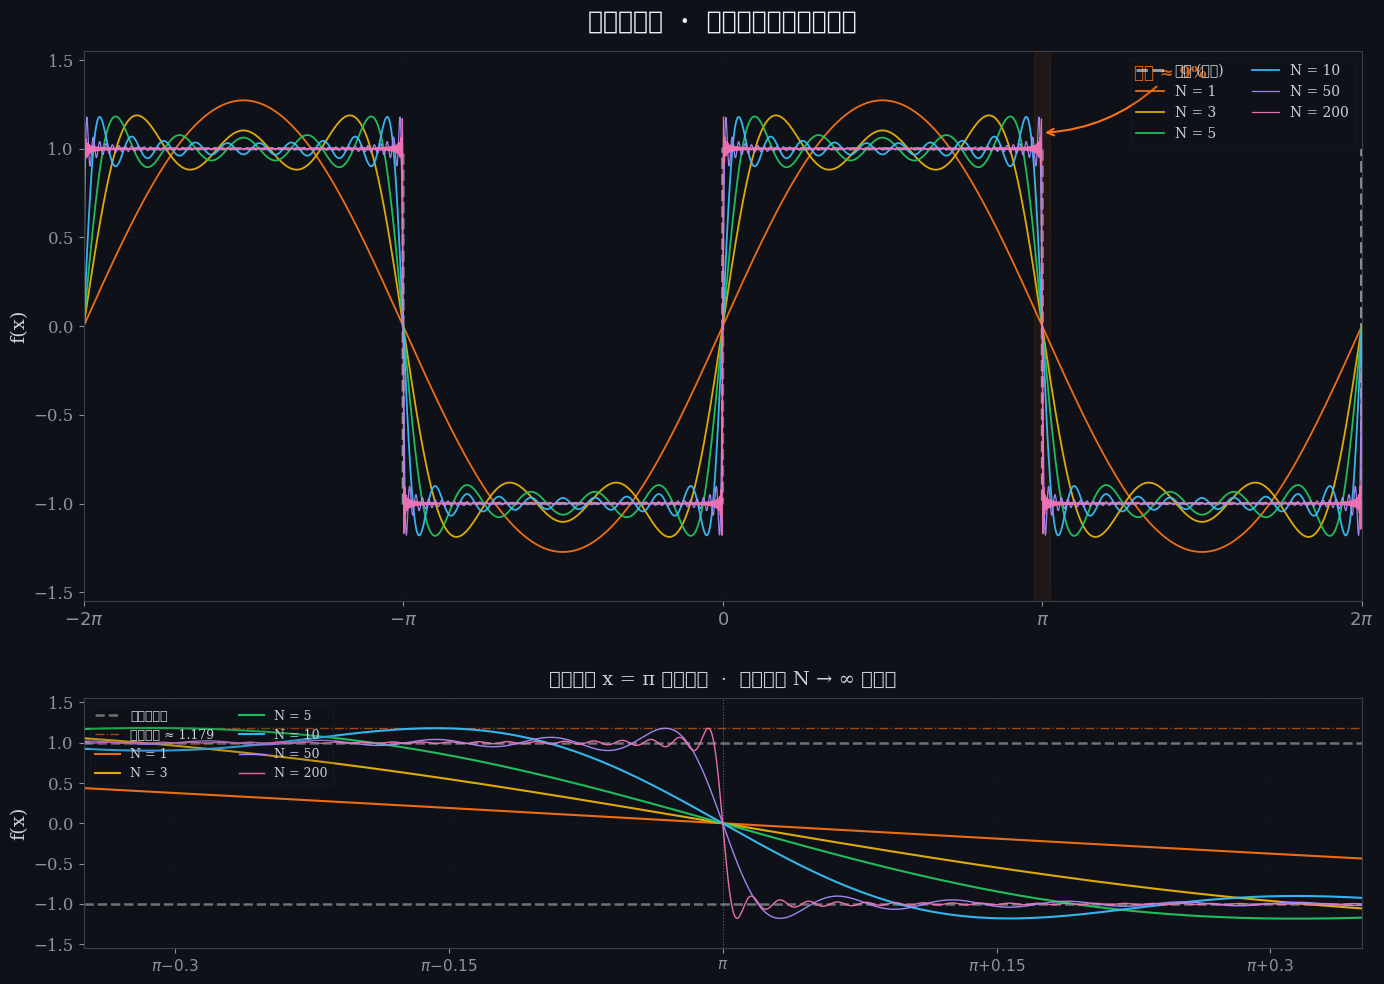

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ── 全局样式 ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#0e1117",
    "axes.edgecolor":   "#3a3f47",
    "axes.labelcolor":  "#c9d1d9",
    "text.color":       "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "grid.color":       "#1c2128",
    "font.family":      "serif",
    "font.size":        12,
})

# ── 方波函数 ──────────────────────────────────────────────
def square_wave(x):
    """周期 2π 的方波，范围 [-π, π)"""
    return np.where(np.mod(x, 2 * np.pi) < np.pi, 1.0, -1.0)

# ── 傅里叶级数部分和 ─────────────────────────────────────
def fourier_square(x, N):
    """方波的前 N 项傅里叶级数逼近"""
    s = np.zeros_like(x, dtype=float)
    for k in range(1, N + 1):
        n = 2 * k - 1          # 仅奇数次谐波: 1, 3, 5, ...
        s += (4.0 / (n * np.pi)) * np.sin(n * x)
    return s

# ── 数据 ──────────────────────────────────────────────────
x = np.linspace(-2 * np.pi, 2 * np.pi, 4000)
N_values = [1, 3, 5, 10, 50, 200]

# ── 颜色方案 ──────────────────────────────────────────────
colors = ["#f97316", "#eab308", "#22c55e", "#38bdf8", "#a78bfa", "#f472b6"]

# ── 绘图 ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10),
                          gridspec_kw={"height_ratios": [2.2, 1]})

# ===== 上图：完整视角 =====
ax = axes[0]
ax.plot(x, square_wave(x), color="#ffffff", linewidth=2.2,
        linestyle="--", alpha=0.55, label="方波 (目标)", zorder=1)

for i, N in enumerate(N_values):
    ax.plot(x, fourier_square(x, N), color=colors[i],
            linewidth=1.3 if N < 50 else 0.9,
            alpha=0.95, label=f"N = {N}", zorder=2)

ax.set_xlim(-2 * np.pi, 2 * np.pi)
ax.set_ylim(-1.55, 1.55)
ax.set_xticks([-2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi])
ax.set_xticklabels([r"$-2\pi$", r"$-\pi$", r"$0$", r"$\pi$", r"$2\pi$"],
                   fontsize=13)
ax.set_ylabel("f(x)", fontsize=14)
ax.set_title("吉布斯现象  ·  方波的傅里叶级数逼近",
             fontsize=18, fontweight="bold", pad=16,
             color="#e6edf3")
ax.legend(loc="upper right", fontsize=10, framealpha=0.15,
          edgecolor="#3a3f47", ncol=2)
ax.grid(True, alpha=0.3)

# 标注过冲区域
overshoot_region = 0.08  # π 附近的窄带
for x0 in [np.pi]:
    ax.axvspan(x0 - overshoot_region, x0 + overshoot_region,
               color="#f97316", alpha=0.08, zorder=0)

# 过冲标注箭头
ax.annotate("过冲 ≈ 9%",
            xy=(np.pi, 1.0897), xytext=(np.pi + 0.9, 1.40),
            fontsize=12, color="#f97316", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#f97316",
                            lw=1.5, connectionstyle="arc3,rad=-0.2"))

# ===== 下图：不连续点附近的放大 =====
ax2 = axes[1]
x_zoom = np.linspace(np.pi - 0.35, np.pi + 0.35, 2000)

ax2.axhline(y=1.0, color="#ffffff", linewidth=1.8, linestyle="--",
            alpha=0.4, label="方波极限值")
ax2.axhline(y=-1.0, color="#ffffff", linewidth=1.8, linestyle="--", alpha=0.4)
ax2.axvline(x=np.pi, color="#ffffff", linewidth=0.8, linestyle=":",
            alpha=0.3)

# 过冲极限线
overshoot_limit = 1.0 + 2 * 0.08949  # ≈ 1.179
ax2.axhline(y=overshoot_limit, color="#f97316", linewidth=1.0,
            linestyle="-.", alpha=0.6, label=f"过冲极限 ≈ {overshoot_limit:.3f}")

for i, N in enumerate(N_values):
    ax2.plot(x_zoom, fourier_square(x_zoom, N), color=colors[i],
             linewidth=1.5 if N < 50 else 1.0,
             alpha=0.95, label=f"N = {N}")

ax2.set_xlim(np.pi - 0.35, np.pi + 0.35)
ax2.set_ylim(-1.55, 1.55)
ax2.set_xticks([np.pi - 0.3, np.pi - 0.15, np.pi,
                np.pi + 0.15, np.pi + 0.3])
ax2.set_xticklabels([r"$\pi\!-\!0.3$", r"$\pi\!-\!0.15$",
                     r"$\pi$", r"$\pi\!+\!0.15$", r"$\pi\!+\!0.3$"],
                    fontsize=11)
ax2.set_ylabel("f(x)", fontsize=14)
ax2.set_title("不连续点 x = π 附近放大  ·  过冲不随 N → ∞ 而消失",
              fontsize=14, pad=10, color="#c9d1d9")
ax2.legend(loc="upper left", fontsize=9, framealpha=0.15,
           edgecolor="#3a3f47", ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout(h_pad=2.5)
# plt.savefig("gibbs_phenomenon.png", dpi=180, bbox_inches="tight")
plt.show()
